In [ ]:
# !pip install -r requirements.txt

In [1]:
# Import Libraries
import google.auth
from google.cloud import storage, aiplatform
import os
import tensorflow_hub as hub
import glob
import dotenv

from vector_search_image_query import create_gcs_bucket, extract_images_from_pdf, list_gcs_image_paths, generate_embedding, query_index, display_results


2025-01-12 01:16:52.350093: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-12 01:16:52.410946: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-12 01:16:52.412824: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-12 01:16:53.422884: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
dotenv.load_dotenv()

True

In [3]:
# Set the GOOGLE_APPLICATION_CREDENTIALS environment variable
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = os.getenv('SERVICE_ACCOUNT_PATH')

In [4]:
# Configuration

credentials, project_id = google.auth.default()

PROJECT_ID = project_id
REGION = "asia-southeast2" 

# Directory structure
PDF_FOLDER = "pdf_files"

# GCS Bucket Name and path for embeddings
GCS_IMAGE_BUCKET_NAME = f"{PROJECT_ID}-extracted-images-from-pdf"  
GCS_BATCH_ROOT = "batch_root"

IMAGE_DIRECTORY = "images" # Local directory, will be replaced with GCS later
MODEL_URL = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/5"
NUM_NEIGHBORS = 3

index_endpoint_name  = "sbi-image-index-endpoint"
deployed_index_id = "indexid_sbi_01_20250110070558"
index_endpoint_resource_name  = "projects/732281804210/locations/asia-southeast2/indexEndpoints/1890174837356232704"

In [5]:
# Initialize Vertex AI SDK
aiplatform.init(project=PROJECT_ID, location=REGION)

In [6]:
# Initialize Google Cloud Storage client
storage_client = storage.Client(project=PROJECT_ID)

# 1. Prepare Image Dataset

In [8]:
# Create or get the GCS bucket
bucket = create_gcs_bucket(GCS_IMAGE_BUCKET_NAME, REGION, storage_client)

Bucket sbi-ai-solution-01-extracted-images-from-pdf already exists.


In [11]:
# Ensure pdf directory exists (optional)
if not os.path.exists(PDF_FOLDER):
    os.makedirs(PDF_FOLDER)
    print(f"Created directory: {PDF_FOLDER}. Add some pdf files into it.")

In [12]:
# Get all PDF files in the specified directory
pdf_files = glob.glob(os.path.join(PDF_FOLDER, "*.pdf"))

if not pdf_files:
    print(f"No PDF files found in the directory: {PDF_FOLDER}.")
else:
    for pdf_file in pdf_files:
        extract_images_from_pdf(pdf_file, IMAGE_DIRECTORY, bucket)

Extracted 19 images from pdf_files/Raw Mill Gear Box Report.pdf and saved to GCS bucket: gs://sbi-ai-solution-01-extracted-images-from-pdf/images


In [10]:
# Get image paths from the GCS bucket

image_paths = list_gcs_image_paths(bucket, IMAGE_DIRECTORY)
if not image_paths:
    print(f"No images found in gs://{bucket.name}/{IMAGE_DIRECTORY}. Please put some images in this GCS folder to continue.")
    exit()  # Stop further execution. You have to place images into the folder.

print(f"Found {len(image_paths)} images in the GCS bucket: gs://{bucket.name}/{IMAGE_DIRECTORY}")

Found 19 images in the GCS bucket: gs://sbi-ai-solution-01-extracted-images-from-pdf/images


# 2. Generate Image Embeddings

In [9]:
# Load a pre-trained ResNet model from TensorFlow Hub
model = hub.KerasLayer(MODEL_URL)

2025-01-10 13:20:02.816256: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
# Generate Embeddings
embeddings = []

for i, path in enumerate(image_paths):
    embedding = generate_embedding(path, bucket, model)
    # Extract file name with extension from GCS path
    file_name_with_extension = os.path.basename(path)

    embedding_record = {
        "id": file_name_with_extension,
        "embedding": embedding.tolist()
    }
    embeddings.append(embedding_record)
    print(f"Generated embedding for image: {os.path.basename(path)}")

Generated embedding for image: Raw Mill Gear Box Report_page_2_img_1.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_2_img_2.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_2_img_3.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_2_img_4.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_3_img_1.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_3_img_2.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_4_img_1.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_4_img_2.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_4_img_3.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_4_img_4.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_5_img_1.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_5_img_2.jpg
Generated embedding for image: Raw Mill Gear Box Report_page_5_img_3.jpg
Generated embedding for image: Raw Mill Gear Box Re

# 3. Query the Index

In [12]:
# Get the index endpoint object from the name
index_endpoint = aiplatform.MatchingEngineIndexEndpoint(index_endpoint_resource_name)

## GCS


Querying using image: gs://sbi-ai-solution-01-extracted-images-from-pdf/gs://sbi-ai-solution-01-extracted-images-from-pdf/images/Raw Mill Gear Box Report_page_2_img_1.jpg
Similar images found:
  - ID: Raw Mill Gear Box Report_page_2_img_1.jpg, Distance: 1643.96630859375


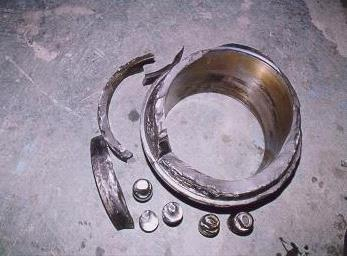

  - ID: Raw Mill Gear Box Report_page_2_img_2.jpg, Distance: 850.1084594726562


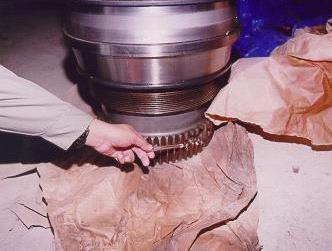

  - ID: Raw Mill Gear Box Report_page_4_img_4.jpg, Distance: 833.9368286132812


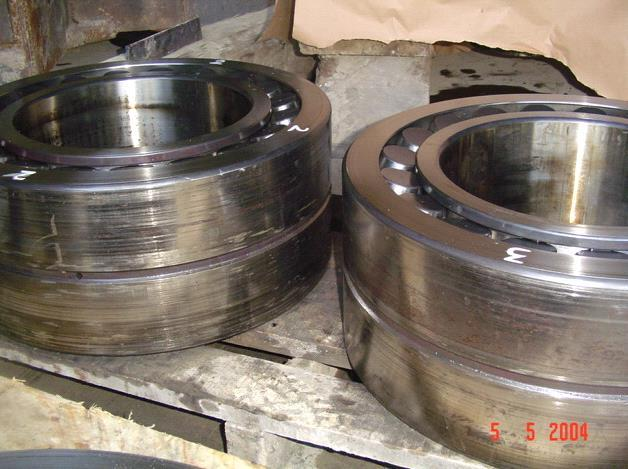

In [13]:
# Example query
if image_paths:
    query_image_path = f"gs://{bucket.name}/{image_paths[0]}" # Use the first image in GCS for example. You can change this.
    query_results = query_index(query_image_path,
                                bucket,
                                model, 
                                index_endpoint, 
                                deployed_index_id, 
                                num_neighbors=NUM_NEIGHBORS)
    print(f"\nQuerying using image: {query_image_path}")
    display_results(query_results, bucket, IMAGE_DIRECTORY)
else:
    print("No images found to query the index.")

# From Local File


Querying using image: Raw Mill Gear Box Report_page_2_img_2.jpg
Similar images found:
  - ID: Raw Mill Gear Box Report_page_2_img_2.jpg, Distance: 3203.25830078125


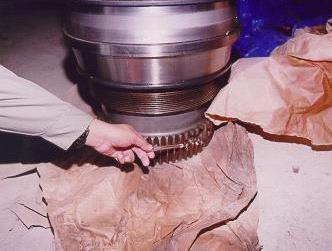

  - ID: Raw Mill Gear Box Report_page_4_img_4.jpg, Distance: 1415.142333984375


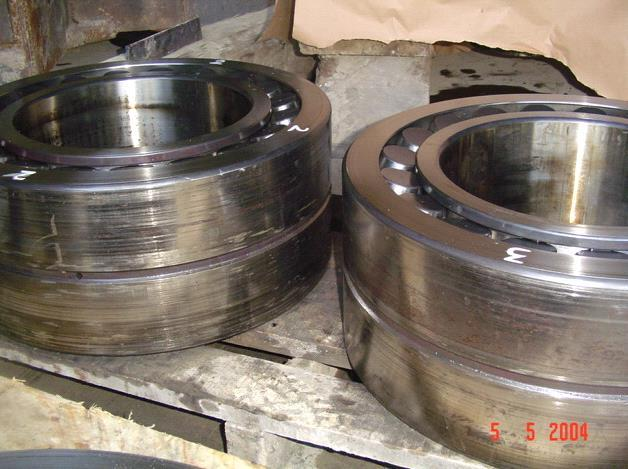

  - ID: Raw Mill Gear Box Report_page_4_img_1.jpg, Distance: 983.127685546875


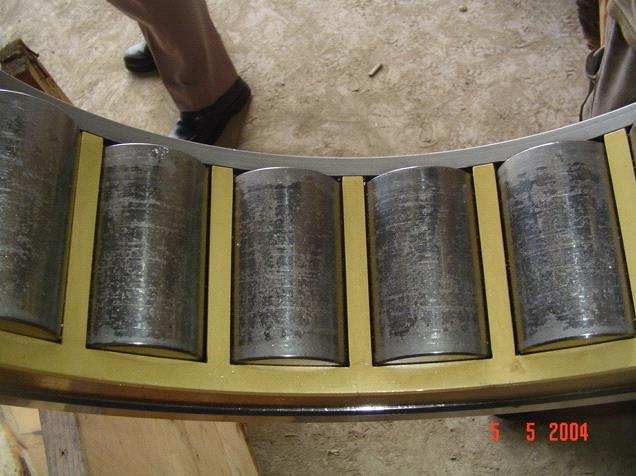

In [15]:
query_image_path = "Raw Mill Gear Box Report_page_2_img_2.jpg"
query_results = query_index(query_image_path,
                                bucket,
                                model, 
                                index_endpoint, 
                                deployed_index_id, 
                                num_neighbors=NUM_NEIGHBORS)
print(f"\nQuerying using image: {query_image_path}")
display_results(query_results, bucket, IMAGE_DIRECTORY)